In [1]:
from pathlib import Path
import pandas as pd

def combine_csvs_with_filename(directory):
    """
    Combine all CSV files in a directory into one DataFrame.
    Adds a 'FileName' column containing the source filename.
    """
    dfs = []

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)
        df["FileName"] = file.name
        dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [2]:
fixed_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/alexFixed/FixedAlex/merged")

Text(0.5, 1.0, 'Distribution of RunTimes in Fixed Alex Culture')

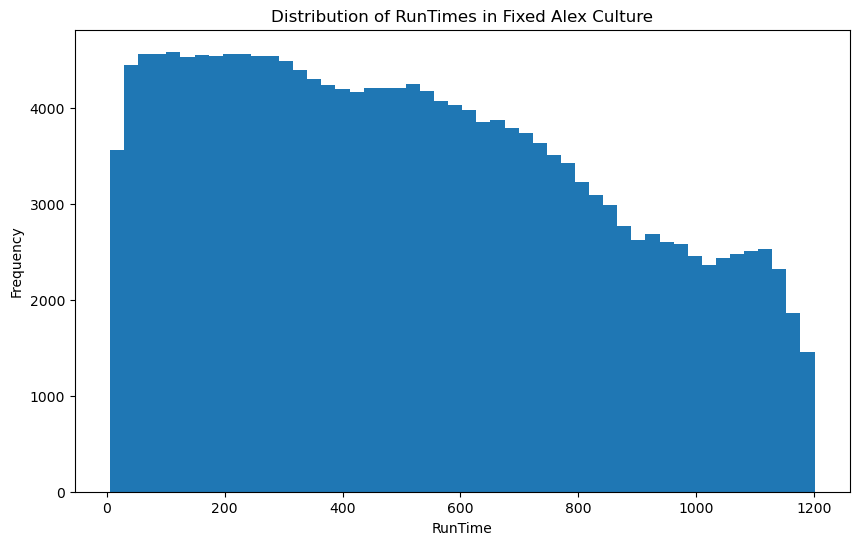

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(fixed_df["RunTime"], bins=50)
plt.xlabel("RunTime")
plt.ylabel("Frequency")
plt.title("Distribution of RunTimes in Fixed Alex Culture")

In [5]:
Roi_df = fixed_df[fixed_df["RoiType"] != 0]
print("Master df shape:", fixed_df.shape)
print("Roi df shape:", Roi_df.shape)

Master df shape: (181395, 14)
Roi df shape: (180325, 14)


Text(0.5, 1.0, 'Distribution of RunTimes in Fixed Alex Culture')

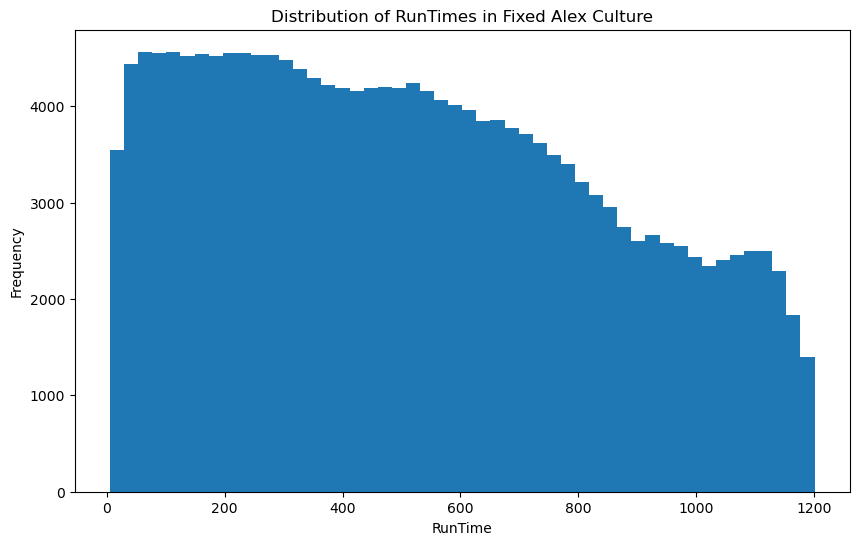

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(Roi_df["RunTime"], bins=50)
plt.xlabel("RunTime")
plt.ylabel("Frequency")
plt.title("Distribution of RunTimes in Fixed Alex Culture")

KS statistic: 0.10608250599063707
p-value: 0.0


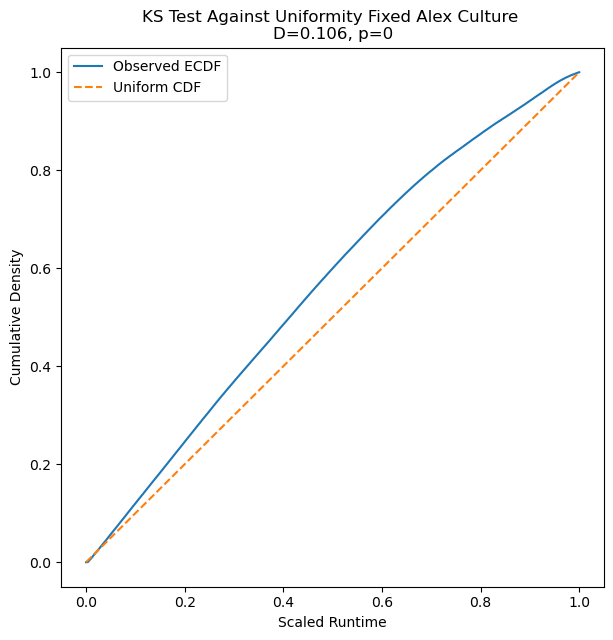

In [7]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(Roi_df["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Fixed Alex Culture \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/chukchi/KS_test_Bivalves.png", dpi=300)

plt.show()

In [8]:
live_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/Alex/hablab_AlexHighV/merged")

Text(0.5, 1.0, 'Distribution of RunTimes: Live Data vs Fixed Alex Culture')

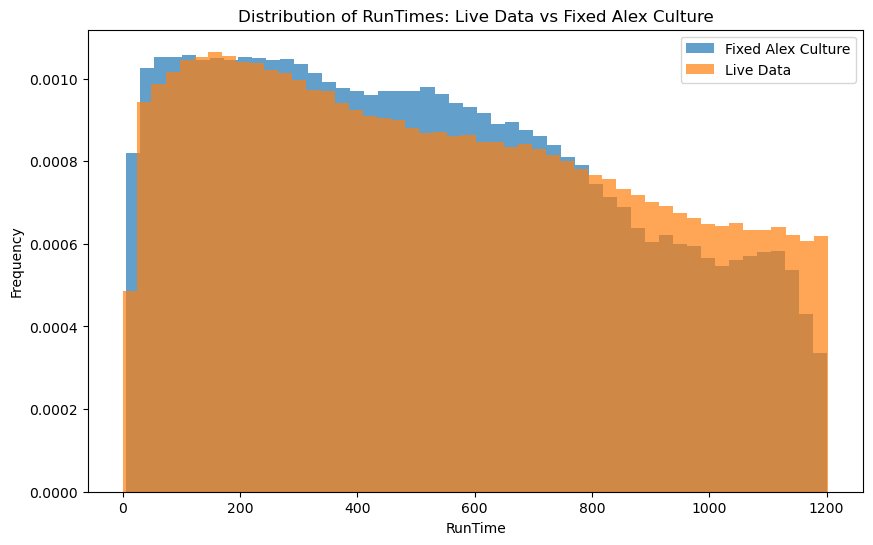

In [36]:
plt.figure(figsize=(10, 6))
plt.hist(fixed_df["RunTime"], bins=50, alpha=0.7, label='Fixed Alex Culture', density=True)
plt.hist(live_df["RunTime"], bins=50, alpha=0.7, label='Live Data', density=True)
plt.xlabel("RunTime")
plt.ylabel("Frequency")
plt.legend()
plt.title("Distribution of RunTimes: Live Data vs Fixed Alex Culture")

In [20]:
## Estimate concentrations for each file
files = fixed_df["FileName"].unique()
particle_counts = {}
volumes = {}
concentrations = {}


for file in files:
    file_df = fixed_df[fixed_df["FileName"] == file]
    file_df = file_df[file_df["RoiType"] != 0]  # Filter out RoiType == 0 if needed
    total_particles = len(file_df)
    particle_counts[file] = total_particles
    total_volume = file_df["VolumeAnalyzed"].max()  # Assuming there's a 'Volume' column
    volumes[file] = total_volume
    concentration = total_particles / total_volume if total_volume > 0 else 0
    concentrations[file] = concentration

concentration_df = pd.DataFrame({
    "FileName": list(concentrations.keys()),
    "ParticleCount": list(particle_counts.values()),
    "VolumeAnalyzed": list(volumes.values()),
    "Concentration": list(concentrations.values()) 
})


In [32]:
concentration_df["datetime"] = pd.to_datetime(
    concentration_df["FileName"].str.slice(1, 16),
    format="%Y%m%dT%H%M%S"
)
concentration_df.head()


,FileName,ParticleCount,VolumeAnalyzed,Concentration,datetime
0,D20260827T011159_IFCB124_adc_only.csv,7276,2.454887,2963.884042,2026-08-27 01:11:59
1,D20260826T194653_IFCB124_adc_only.csv,7205,2.492066,2891.175131,2026-08-26 19:46:53
2,D20260826T222927_IFCB124_adc_only.csv,7177,2.496538,2874.781439,2026-08-26 22:29:27
3,D20260827T024452_IFCB124_adc_only.csv,7302,2.455397,2973.857542,2026-08-27 02:44:52
4,D20260826T183713_IFCB124_adc_only.csv,6893,2.577288,2674.516427,2026-08-26 18:37:13


/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_55614/1516502925.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([concentration_df["Concentration"]], labels=["Fixed Alex Culture"])


Text(0, 0.5, 'Concentration (particles per unit volume)')

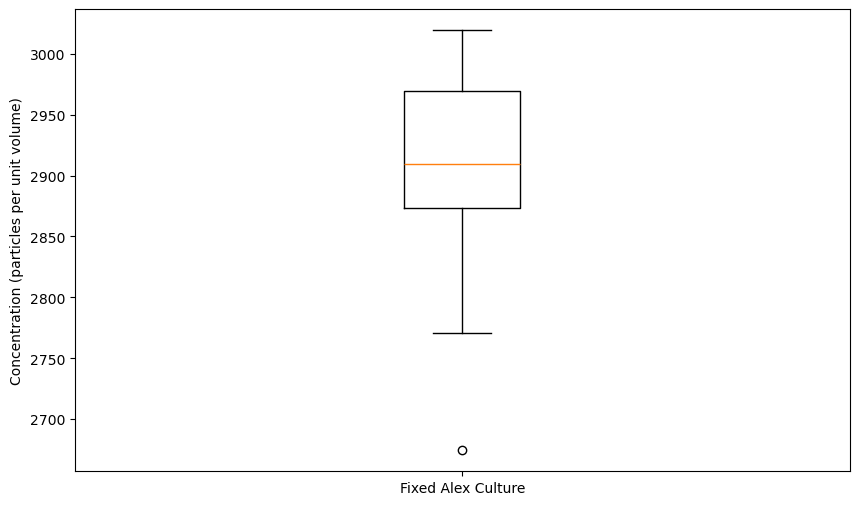

In [27]:
plt.figure(figsize=(10, 6))
plt.boxplot([concentration_df["Concentration"]], labels=["Fixed Alex Culture"])
plt.ylabel("Concentration (particles per unit volume)")

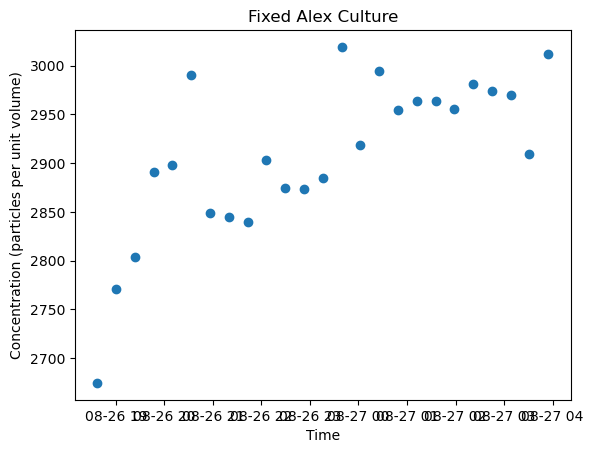

In [34]:
plt.scatter(concentration_df["datetime"], concentration_df["Concentration"])
plt.xlabel("Time")
plt.ylabel("Concentration (particles per unit volume)")
plt.title("Fixed Alex Culture")
plt.show()

In [10]:
fixed_df["condition"] = "fixed"
live_df["condition"] = "live"


In [26]:
fixed_df.columns.to_list()

['trigger#',
 'RoiNumber',
 'PMTB',
 'ADCtime',
 'RunTime',
 'InhibitTime',
 'InhibitTimeDiff',
 'VolumeAnalyzed',
 'RoiType',
 'RoiHeight',
 'RoiWidth',
 'RoiX',
 'RoiY',
 'FileName',
 'condition']

In [13]:
master_df = pd.concat([fixed_df, live_df], ignore_index=True)


In [14]:
master_df.columns.to_list()

['trigger#',
 'RoiNumber',
 'PMTB',
 'ADCtime',
 'RunTime',
 'InhibitTime',
 'InhibitTimeDiff',
 'VolumeAnalyzed',
 'RoiType',
 'RoiHeight',
 'RoiWidth',
 'RoiX',
 'RoiY',
 'FileName',
 'condition']

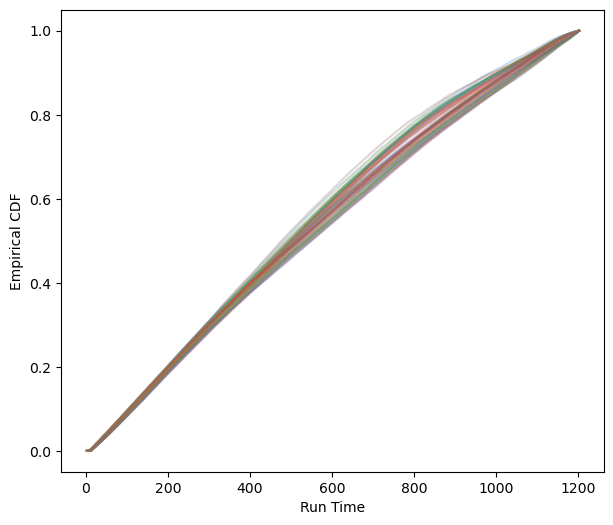

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

for (condition, filename), group in master_df.groupby(["condition", "FileName"]):

    x = np.sort(group["RunTime"].dropna())
    y = np.arange(1, len(x) + 1) / len(x)

    alpha = 0.25

    if condition == "Fixed":
        ax.plot(x, y, alpha=alpha)
    else:
        ax.plot(x, y, alpha=alpha)

ax.set_xlabel("Run Time")
ax.set_ylabel("Empirical CDF")
plt.show()

In [ ]:
## Trying some new metric for how to compare the two distributions


In [16]:
import pandas as pd
from scipy.stats import wasserstein_distance
from itertools import combinations

def pairwise_wasserstein(df, value_col, run_col="FileName", condition_col="condition"):

    # Store each run's observations
    runs = {
        run: group[value_col].dropna().values
        for run, group in df.groupby(run_col)
    }

    # Condition associated with each run
    conditions = (
        df.groupby(run_col)[condition_col]
        .first()
        .to_dict()
    )

    results = []

    for run1, run2 in combinations(runs.keys(), 2):

        distance = wasserstein_distance(
            runs[run1],
            runs[run2]
        )

        cond1 = conditions[run1]
        cond2 = conditions[run2]

        if cond1 == cond2:
            comparison = f"Within {cond1}"
        else:
            comparison = "Between treatments"

        results.append({
            "run1": run1,
            "run2": run2,
            "condition1": cond1,
            "condition2": cond2,
            "comparison": comparison,
            "wasserstein_distance": distance
        })

    return pd.DataFrame(results)

In [17]:
wd_df = pairwise_wasserstein(
    master_df,
    value_col="RunTime"
)

In [38]:
print(wd_df.head())

                                    run1  \
0  D20260304T211303_IFCB149_adc_only.csv   
1  D20260304T211303_IFCB149_adc_only.csv   
2  D20260304T211303_IFCB149_adc_only.csv   
3  D20260304T211303_IFCB149_adc_only.csv   
4  D20260304T211303_IFCB149_adc_only.csv   

                                    run2 condition1 condition2   comparison  \
0  D20260304T215934_IFCB149_adc_only.csv       live       live  Within live   
1  D20260304T224605_IFCB149_adc_only.csv       live       live  Within live   
2  D20260304T233236_IFCB149_adc_only.csv       live       live  Within live   
3  D20260305T001907_IFCB149_adc_only.csv       live       live  Within live   
4  D20260305T010538_IFCB149_adc_only.csv       live       live  Within live   

   wasserstein_distance  
0             24.075741  
1             28.242118  
2             36.653207  
3             12.829892  
4             29.302062  


In [18]:
wd_df.groupby("comparison")["wasserstein_distance"].describe()

,count,mean,std,min,25%,50%,75%,max
comparison,,,,,,,,
Between treatments,1275.0,23.855155,10.427399,4.436903,15.564667,22.153124,32.314837,54.385488
Within fixed,300.0,6.238119,3.512782,1.851450,3.711516,5.194684,8.018931,20.209320
Within live,1275.0,13.112085,9.376753,1.438390,5.406191,10.718298,18.694005,54.670468


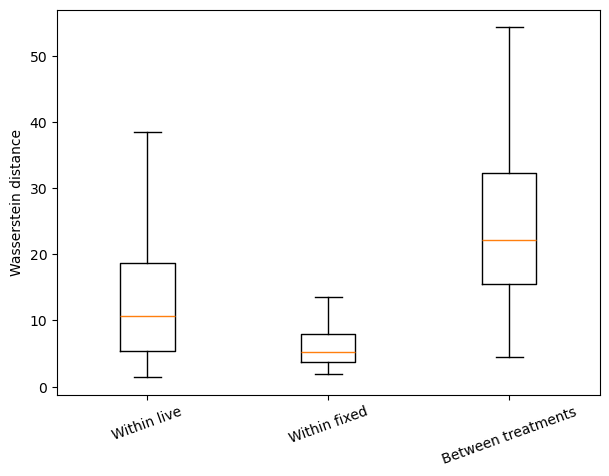

In [40]:
import matplotlib.pyplot as plt

groups = [
    "Within live",
    "Within fixed",
    "Between treatments"
]

data = [
    wd_df.loc[
        wd_df["comparison"] == group,
        "wasserstein_distance"
    ]
    for group in groups
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    data,
    tick_labels=groups,
    showfliers=False
)

plt.ylabel("Wasserstein distance")
plt.xticks(rotation=20)
plt.show()